<table  align="left" width="100%"> <tr>
        <td  style="background-color:#ffffff;"><a href="https://qworld.net" target="_blank"><img src="../images/qworld/qworld.jpg" width="35%" align="left"></a></td>
        <td  align="right" style="background-color:#ffffff;vertical-align:bottom;horizontal-align:right">
            prepared by Özlem Salehi Köken
        </td>        
</tr></table>

# <font color="blue"> Solutions for </font> Continuous Time Evolution

In [5]:
import numpy as np
np.set_printoptions(precision=2, suppress=True)


<a id="Task1"> </a>

### Task 1

For  $H= X+Z$ , compute $U(t,t_0) = \exp \left(-iH\cdot(t-t_0)\right)$ for $t_0=0$ and $t=1$ in Python, using the identity $exp(A) = P\exp(D)P^{-1}$.

In [ ]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np
from scipy.linalg import eig
np.set_printoptions(precision=6, suppress=True)

X = np.array([[0, 1], [1, 0]])
Z = np.array([[1 ,0], [0, -1]])
H = X+Z

### Your code here

[[0.155944-0.698456j 0.      -0.698456j]
 [0.      -0.698456j 0.155944+0.698456j]]


### Solution

In [ ]:
import numpy as np
from scipy.linalg import eig

X = np.array([[0, 1], [1, 0]])
Z = np.array([[1 ,0], [0, -1]])
H = X+Z

eigenvalues, eigenvectors = eig(H)
P = eigenvectors
D = np.diag(eigenvalues)
P_inv = np.linalg.inv(P)
expD = np.diag(np.exp(-1j * 1* np.diagonal(D)))
result = P @ expD @ P_inv
print(result)

[[0.16-0.7j 0.  -0.7j]
 [0.  -0.7j 0.16+0.7j]]


<a id="Task2"> </a>

### Task 2

Compute $U(t,t_0) = \exp \left(-iH\cdot(t-t_0)\right)$ for $t_0=0$, $t=\pi$, and $H=Z$ on paper, using the matrix exponentials for Pauli operators.

### Solution

We want to compute $
U(\pi, 0) = \exp\left( -i Z \pi \right).
$

Recall that,
\begin{align}
exp({-i Z t})  = \begin{pmatrix}
                  e^{-it} & 0 \\
                  0 & e^{it}
                  \end{pmatrix} = R_z(2t).
\end{align}

Thus we can write $U(\pi, 0) = R_z(2\pi)$ and $
R_z(2\pi) = \begin{pmatrix}
e^{-i \pi} & 0 \\
0 & e^{i \pi}
\end{pmatrix}
.$

Since $ e^{i \pi} = -1 $ and $ e^{-i \pi} = -1 $, we get

$$
R_z(2\pi) = \begin{pmatrix}
-1 & 0 \\
0 & -1
\end{pmatrix} .
$$

Therefore, the unitary evolution operator is:
$$
\begin{pmatrix}
-1 & 0 \\
0 & -1
\end{pmatrix}.
$$

Note that evolution under the Hamiltonian $Z$ corresponds to a rotation of the qubit state around the $Z$-axis on the Bloch sphere.

<a id="Task3"> </a>

### Task 3

For $H=Z$ and $t=\pi/2$, obtain the unitary matrix using Qiskit in three different ways:
- Implement $R_z(\theta)$ with the corresponding angle.
- Use `HamiltonianGate` from Qiskit, which takes as input the Hamiltonian and the duration of the evolution and returns the corresponding unitary.
- Use `PauliEvolutionGate` from Qiskit, which takes as input the Hamiltonian and the duration of the evolution and returns the corresponding unitary.

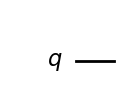

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from math import pi

#Your code here

qcOp = Operator.from_circuit(qc)
qcOp.draw('latex')

In [ ]:
from qiskit.circuit.library import HamiltonianGate
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Operator
from math import pi

#Your code here

print(hgate.to_matrix())

In [ ]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
from math import pi

#Your code here

print(pgate.to_matrix())

<IPython.core.display.Latex object>

### Solution

In [9]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from math import pi

qc = QuantumCircuit(1)
qc.rz(pi,0)
qcOp = Operator.from_circuit(qc)
qcOp.draw('latex')

<IPython.core.display.Latex object>

In [10]:
from qiskit.circuit.library import HamiltonianGate
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from math import pi

H = SparsePauliOp(['Z'], coeffs=[1])
hgate = HamiltonianGate(H, time=pi/2)
print(hgate.to_matrix())

[[0.-1.j 0.+0.j]
 [0.+0.j 0.+1.j]]


In [11]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from math import pi

qc = QuantumCircuit(1)
op = SparsePauliOp(['Z'], coeffs=[1])
pgate = PauliEvolutionGate(op, pi/2)
print(pgate.to_matrix())


[[0.-1.j 0.+0.j]
 [0.+0.j 0.+1.j]]


/opt/anaconda3/envs/cs440/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/opt/anaconda3/envs/cs440/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


<a id="Task4"> </a>

### Task 4
For $H=X+Z$, construct the gates `HamiltonianGate` and `PauliEvolutionGate` from Qiskit and append them to a quantum circuit. Compare the two results you obtain with the result of Task 1. What can you conclude by looking at the circuits?

In [ ]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from math import pi

qc = QuantumCircuit(1)

### Your code here

print(qc.decompose().draw())
print(evo.to_matrix())


   ┌───────┐┌───────┐
q: ┤ Rx(2) ├┤ Rz(2) ├
   └───────┘└───────┘


<IPython.core.display.Latex object>

In [ ]:
from qiskit.quantum_info import Operator
from qiskit.circuit.library import HamiltonianGate
from qiskit import QuantumCircuit
from math import pi

qc = QuantumCircuit(1)

### Your code here

print(qc.decompose(reps=2).draw())
print(hgate.to_matrix())

global phase: 4.9321
   ┌───────────────────────────┐
q: ┤ U(1.5465,-0.21967,2.9219) ├
   └───────────────────────────┘


<IPython.core.display.Latex object>

### Solution


In [19]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from math import pi

qc = QuantumCircuit(1)
op = SparsePauliOp(['X', 'Z'], coeffs=[1, 1])
evo = PauliEvolutionGate(op,1)
qc.append(evo, [0])
print(qc.decompose().draw())
print(evo.to_matrix())


   ┌───────┐┌───────┐
q: ┤ Rx(2) ├┤ Rz(2) ├
   └───────┘└───────┘
[[0.16-0.7j 0.  -0.7j]
 [0.  -0.7j 0.16+0.7j]]


/opt/anaconda3/envs/cs440/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/opt/anaconda3/envs/cs440/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


In [21]:
from qiskit.quantum_info import Operator
from qiskit.circuit.library import HamiltonianGate
from qiskit import QuantumCircuit
from math import pi

qc = QuantumCircuit(1)
op = SparsePauliOp(['X', 'Z'], coeffs=[1, 1])
hgate = HamiltonianGate(op, 1)
qc.append(hgate,[0])
print(qc.decompose(reps=2).draw())
print(hgate.to_matrix())

global phase: 4.9321
   ┌───────────────────────────┐
q: ┤ U(1.5465,-0.21967,2.9219) ├
   └───────────────────────────┘
[[0.16-0.7j 0.  -0.7j]
 [0.  -0.7j 0.16+0.7j]]


If we check the quantum circuit from the first code, we see that $R_X$ and $R_Z$ gates are implemented consecutively. The circuit implements $\exp(-iX) exp(-iZ)$ which approximates $\exp(-i(X+Z))$.

The reason is that `PauliEvolutionGate`is implemented using Lie-Trotter product formula with a single repetition $n=1$:

$$\exp(A+B) = \lim_{n → \infty} \left (exp\left (\frac{A}{n} \right )exp\left (\frac{B}{n} \right ) \right)^n.$$

Hence, $\exp(-i(X+Z))$ is implemented as $\exp(-iX)\exp(-iZ)$.

The second code implements the circuit exactly, which can be verified by Task 1.

Note that `HamiltonianGate` is also not exact for more than 2 qubits.

<a id="Task5"> </a>


### Task 5

For $H_i = XII + IXI + IIX$ and $H_f = XZX+YZY+ZZZ$, plot the eigenvalues of the Hamiltonian  $H(t) = (1-t/T)H_i + (t/T)H_f$ for starting from $t=0$ to $t=T=50$. For each eigenvalue, use a different color.

In [ ]:
from qiskit.quantum_info import SparsePauliOp
import scipy
import matplotlib.pyplot as plt

# Define the Hamiltonians
T=50

for t in range(T):
  # Compute H_t and its eigenvalues


  for i in range(len(eigenvalues)):
    color = plt.cm.tab10(i)
    # Add the value of each eigenvalue at time t to the plot



### Solution

/opt/anaconda3/envs/cs440/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


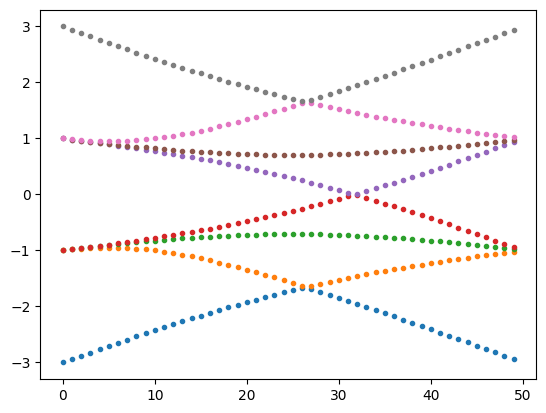

In [12]:
from qiskit.quantum_info import SparsePauliOp
import scipy
import matplotlib.pyplot as plt

# Define the Hamiltonians
Hi =  SparsePauliOp(["XII","IXI","IIX"], [1,1,1])
Hf =  SparsePauliOp(["XZX","YZY","ZZZ"], [1,1,1])
T=50

for t in range(T):
  # Find H_t and its eigenvalues
  Ht = (1-t/T)*Hi + t/T*Hf
  eigenvalues, _ = scipy.linalg.eig(Ht.to_matrix())
  for i in range(len(eigenvalues)):
    color = plt.cm.tab10(i)
    # Add the value of each eigenvalue at time t to the plot
    plt.scatter(t, sorted(eigenvalues)[i], color = color, marker = ".")



